In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Network

In [2]:
from pandapower.converter.matpower import from_mpc
import pandapower as pp

mat_path = "case56sce.mat"
net = from_mpc(mat_path, f_hz=60)
pp.runpp(net, max_iteration=10, numba=False)
print(net.res_bus)

       vm_pu  va_degree      p_mw    q_mvar
0   1.000000   0.000000 -3.558975 -1.912276
1   0.990921  -0.431619  0.000000  0.000000
2   0.990570  -0.429868  0.051300  0.024852
3   0.982914  -0.820684  0.000000  0.000000
4   0.981966  -0.817271  0.108900  0.052756
5   0.982612  -0.822629  0.044100  0.021364
6   0.979304  -0.879386  0.047700  0.023108
7   0.977037  -0.915710  0.042300  0.020492
8   0.975984  -0.910950  0.061200  0.029648
9   0.974384  -0.958520  0.043200  0.020928
10  0.972582  -0.987770  0.060300  0.029212
11  0.971424  -0.998664  0.084600  0.040984
12  0.971137  -1.011266  0.000000  0.000000
13  0.970845  -1.009792  0.051300  0.024852
14  0.969838  -1.032386  0.000000  0.000000
15  0.969429  -1.030301  0.047700  0.023108
16  0.969477  -1.038231  0.051300  0.024852
17  0.967779  -1.057356  0.100800  0.048832
18  0.966522  -1.050955  0.078300  0.037932
19  0.977041  -1.106604  0.000000  0.000000
20  0.976921  -1.105999  0.000000  0.000000
21  0.976052  -1.101605  0.05670

/opt/homebrew/lib/python3.11/site-packages/pandapower/converter/pypower/from_ppc.py:334: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo


In [3]:
def admittance_matrix(filename):
    net = from_mpc(filename, f_hz=60)

    # compute the admittance matrix
    pp.runpp(net, numda=False, max_iteration=10, numba=False)

    matrix_Y = np.array(net._ppc["internal"]["Ybus"].todense())
    matrix_Y0 = matrix_Y.copy()
    # Exclude slack bus to get Z
    matrix_Y = matrix_Y[1:, :]
    matrix_Y = matrix_Y[:, 1:]
    matrix_Z = np.linalg.inv(matrix_Y)

    matrix_XX = np.imag(matrix_Z)
    matrix_RR = np.real(matrix_Z) 

    return matrix_Y, matrix_Y0, matrix_Z, matrix_RR, matrix_XX


matrix_Y, matrix_Y0, _, RR, XX = admittance_matrix(mat_path) # p.u.
num_node = matrix_Y.shape[0]

BB = np.hstack([RR, XX]) # BB.shape (55, 110)

/opt/homebrew/lib/python3.11/site-packages/pandapower/converter/pypower/from_ppc.py:334: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo


In [4]:
np.save("SCE56_network.npy", BB)
np.save("SCE56_network_admitance.npy", matrix_Y0)

## Load Data

In [5]:
### Reference load in [Farivar, 2012 PES GM]

p_ref_total = net.res_bus.iloc[0, 2] # a negative number
q_ref_total = net.res_bus.iloc[0, 3] # a negative number

p_ref = net.res_bus.iloc[1:, 2].to_numpy()
q_ref = net.res_bus.iloc[1:, 3].to_numpy()

In [6]:
### Load variation
rng = np.random.default_rng(seed = 250)
horizon = 2880 * 2
load_variation = rng.uniform(-0.6, 0.6, size=(num_node, horizon))

In [7]:
### Construct the full load data
scale_factor1 = 1.2


p_arr = np.zeros((num_node, horizon))
q_arr = np.zeros((num_node, horizon))

p_arr[:, 0] = p_ref * scale_factor1
q_arr[:, 0] = q_ref * scale_factor1
saturated_num = 0

rng = np.random.default_rng(seed = 200)

### indepdent historical data and saturate load to make it within[-50%, 50%]
for t in range(horizon-1):
    for i in range(num_node):
        p_arr[i, t+1] = p_arr[i, 0] * (load_variation[i, t+ 1] + 1)
        q_arr[i, t+1] = q_arr[i, 0] * (load_variation[i, t+ 1] + 1) * (1 + np.max(0.2 * rng.normal(0, 1), -1))
        #print((load_variation[i, t+ 1] + 1) * (1 + np.max(0.2 * rng.normal(0, 1), -1)))
        if q_arr[i, 0] > 0:
                if ((q_arr[i, t+1] - q_arr[i, 0]) / q_arr[i, 0]) >= 0.6:
                        q_arr[i, t+1] = 1.6 * q_arr[i, 0]
                        print('Saturated Max')
                        saturated_num += 1
                elif ((q_arr[i, t+1] - q_arr[i, 0]) / q_arr[i, 0]) <= -0.6:
                        q_arr[i, t+1] = 0.4 * q_arr[i, 0]  
                        print('Saturated Min')
                        saturated_num += 1


Saturated Min
Saturated Min
Saturated Min
Saturated Min
Saturated Max
Saturated Min
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Min
Saturated Min
Saturated Min
Saturated Max
Saturated Max
Saturated Min
Saturated Min
Saturated Min
Saturated Max
Saturated Max
Saturated Min
Saturated Max
Saturated Max
Saturated Max
Saturated Min
Saturated Max
Saturated Min
Saturated Max
Saturated Max
Saturated Min
Saturated Min
Saturated Max
Saturated Min
Saturated Min
Saturated Min
Saturated Max
Saturated Min
Saturated Min
Saturated Max
Saturated Max
Saturated Min
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Min
Saturated Max
Saturated Max
Saturated Max
Saturated Min
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Min
Saturated Min
Saturated Max
Saturated Max
Saturated Min
Saturated Max
Saturated Max
Saturated Max
Saturated Max
Saturated Min
Satura

In [8]:
np.save("HICSS_data_load_p.npy", p_arr)
np.save("HICSS_data_load_q.npy", q_arr)

## PV Data

In [9]:
### Site selection
random.seed(7)

node_list = list(range(20, num_node+1))

print(node_list)

# install the inverter with different capacity rates
pv1_num = 3
pv2_num = 2 
pv3_num = 2  

pv_1 = random.sample(node_list, pv1_num)

remaining_elements = [elem for elem in node_list if elem not in pv_1]
pv_2 = random.sample(remaining_elements, pv2_num)

remaining_elements = [elem for elem in remaining_elements if elem not in pv_2]
pv_3 = random.sample(remaining_elements, pv3_num)

remaining_elements = [elem for elem in remaining_elements if elem not in pv_3]

print(np.array(pv_1) - 1)
print(np.array(pv_2) -1)
print(np.array(pv_3) -1)

p_pv_ref = np.zeros(num_node)
q_pv_ref = np.zeros(num_node)

# assign operation data
for j in range(num_node):
        if j+1 in pv_1: # notice it is j+ 1 !!!!
            p_pv_ref[j] =  (250 / 2050)
            q_pv_ref[j] = 0.3 * p_pv_ref[j]  # cos theta = 0.95
        elif j+1 in pv_2:
            p_pv_ref[j] = (300 / 2050)
            q_pv_ref[j] = 0.3 * p_pv_ref[j]  
        elif j+1 in pv_3:
            p_pv_ref[j] = (350 / 2050)
            q_pv_ref[j] = 0.3 * p_pv_ref[j] 


[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]
[39 28 44]
[22 23]
[50 40]


In [10]:
### PV Variation
rng = np.random.default_rng(seed = 23)
p_pv_variation = rng.uniform(-1, 1.0, size=(num_node, horizon))
rng = np.random.default_rng(seed = 2)
q_pv_variation = rng.uniform(-1.5, 1., size=(num_node, horizon))

In [11]:
### Construct the full pv data
scale_factor2 = 5.05

rng = np.random.default_rng(seed=5)

p_pv_arr = np.zeros((num_node, horizon))
q_pv_arr = np.zeros((num_node, horizon))

p_pv_arr[:, 0] = p_pv_ref * scale_factor2
q_pv_arr[:, 0] = q_pv_ref * scale_factor2

for t in range(horizon-1):
    for i in range(num_node):
        p_pv_arr[i, t+1] = p_pv_arr[i, 0] * (p_pv_variation[i, t+1] + 1)
        if (p_pv_variation[i, t+1] + 1) >= 1:
            q_pv_arr[i, t+1] = q_pv_arr[i, 0] * (q_pv_variation[i, t+1] + 1)
        else:
            q_pv_arr[i, t+1] = q_pv_arr[i, 0] * (p_pv_variation[i, t+1] + 1) * (1 + np.max(0.2 * rng.normal(0, 1), -1))
            if q_pv_arr[i, 0] > 0:
                if ((q_pv_arr[i, t+1] - q_pv_arr[i, 0]) / q_pv_arr[i, 0]) >= 1:
                    q_pv_arr[i, t+1] = 2 * q_pv_arr[i, 0]
                    print('Saturated Max')

In [12]:
np.save("HICSS_data_pv_p.npy", p_pv_arr)
np.save("HICSS_data_pv_q.npy", q_pv_arr)

## Visualization

Since load and pv data are not spatial-temporal correlated but p & q correlated, we exhibit the correlatiom between p and q at one bus across the time

50
0.8999568031101512


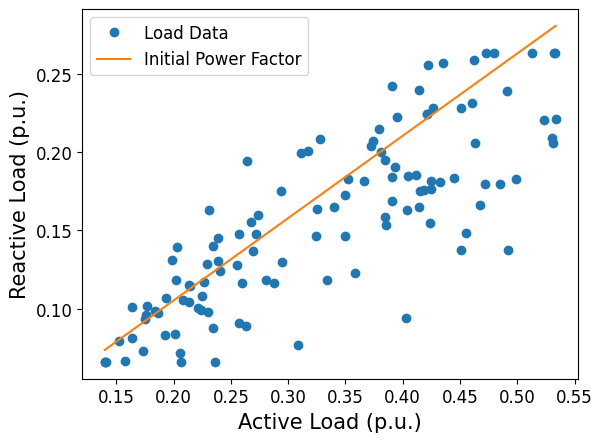

In [13]:
### Visualize the correlation of pv p and q at one bus across the time
bus1 = np.argmax(p_arr[:, 0])
print(bus1)

p_test = p_arr[bus1, ::50]
q_test = q_arr[bus1, ::50]

slope = np.tan(q_arr[bus1, 0] / p_arr[bus1, 0])
print(p_arr[bus1, 0] / (np.sqrt(p_arr[bus1, 0] ** 2 + q_arr[bus1, 0] ** 2)))

xx = np.linspace(np.min(p_test), np.max(p_test), 50)
yy = xx * slope
plt.plot(p_test, q_test, 'o', label='Load Data')
plt.plot(xx, yy, label='Initial Power Factor')

label_x = fr"Active Load (p.u.)"
plt.xlabel(label_x, fontsize = 15)
label_y = fr"Reactive Load (p.u.)"
plt.ylabel(label_y, fontsize = 15)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(fontsize=12)
#plt.title('Target Node #{}'.format(target_node), fontsize = 15)

plt.show()

40
0.9578262852211514


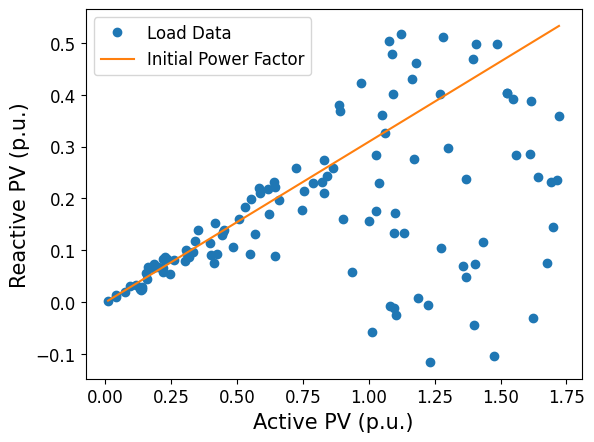

In [14]:
### Visualize the correlation of load p and q at one bus across the time
bus2 = np.argmax(p_pv_arr[:, 0])
print(bus2)

p_test = p_pv_arr[bus2, ::50]
q_test = q_pv_arr[bus2, ::50]

slope = np.tan(q_pv_arr[bus2, 0] / p_pv_arr[bus2, 0])
print(p_pv_arr[bus2, 0] / (np.sqrt(p_pv_arr[bus2, 0] ** 2 + q_pv_arr[bus2, 0] ** 2)))

xx = np.linspace(np.min(p_test), np.max(p_test), 100)
yy = xx * slope
plt.plot(p_test, q_test, 'o', label='Load Data')
plt.plot(xx, yy, label='Initial Power Factor')

label_x = fr"Active PV (p.u.)"
plt.xlabel(label_x, fontsize = 15)
label_y = fr"Reactive PV (p.u.)"
plt.ylabel(label_y, fontsize = 15)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(fontsize=12)
#plt.title('Target Node #{}'.format(target_node), fontsize = 15)

plt.show()